# Convolution: Sharpening and Blurring

This notebook explains **convolution**, the operation behind almost every image filter, and uses it to **sharpen** and **blur** an image with OpenCV. Blurring is the standard first step of a lane detection pipeline: it removes small noise before edge detection, so that the edge detector finds lane lines instead of asphalt texture.

**What it does:**
1. Explains convolution with pictures: a kernel slides over the image, and every output pixel is a weighted sum of its neighbours.
2. Loads the sample image `Self_Driving_Car.jpg` and converts it to grayscale.
3. **Sharpens** the image with two sharpening kernels, explains why they work and compares them with **unsharp masking**.
4. **Blurs** the image with a box kernel and shows why the kernel must be **normalised**.
5. Compares **kernel sizes** (3 × 3, 8 × 8, 15 × 15) and explains why odd sizes are preferred.
6. Compares OpenCV's blur methods: **box**, **Gaussian**, **median** and **bilateral**.
7. Shows why blurring matters for lane detection: **Canny edges with and without a Gaussian blur**.
8. Saves the results and ends with a conclusion.

**How it is implemented:**
- All images are shown inline with **matplotlib**. `cv2.imshow` / `cv2.waitKey` are not used, because they open separate windows, which don't work in Jupyter, Colab, VS Code or on a server without a display.
- Kernels are defined once in the configuration cell and shown as labelled heat maps, so you can see the numbers you are convolving with.
- Tasks with several possible solutions (applying a kernel, sharpening, blurring, showing images) are **reusable functions** with type hints and docstrings.
- Whenever two methods should give the same result (e.g. `cv2.filter2D` with a normalised box kernel and `cv2.blur`), the notebook checks it.
- Zoomed crops and an intensity profile make the small differences between filters visible.
- File paths use `pathlib`, and a missing image or a failed save raises a clear error.

## 1. Imports

- `cv2` (OpenCV): image I/O and filtering
- `matplotlib`: displaying images and plots
- `numpy`: array operations
- `pathlib`: file paths that work on any OS

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

plt.rcParams["figure.dpi"] = 80  # keeps the saved notebook small

## 2. What is a convolution?

A **kernel** (also called a filter or mask) is a small grid of numbers, typically 3 × 3. To filter an image, the kernel is placed on top of every pixel in turn:

1. Multiply each kernel value with the image pixel underneath it.
2. Add up all the products.
3. Write the sum into the output image at the position of the kernel's centre.

$$\text{out}(y, x) = \sum_{i}\sum_{j} \text{kernel}(i, j)\cdot \text{image}(y + i,\; x + j)$$

The kernel decides what the filter does:
- **All values positive and equal** → every output pixel is the average of its neighbourhood → **blur**.
- **Large positive centre, negative neighbours** → the pixel is pushed away from its neighbours' average → **sharpen**.
- **The sum of the kernel** is the brightness gain. A sum of 1 keeps the overall brightness, a sum of 9 makes the image 9 × brighter (and mostly white, because values are clipped at 255).

> 💡 Strictly speaking, `cv2.filter2D` computes a **correlation**: it doesn't flip the kernel as the mathematical convolution does. For symmetric kernels, like all kernels in this notebook, the two are identical.

The picture below runs one step by hand on a tiny 6 × 6 image with a vertical edge (dark on the left, bright on the right), using the 4-neighbour sharpening kernel.

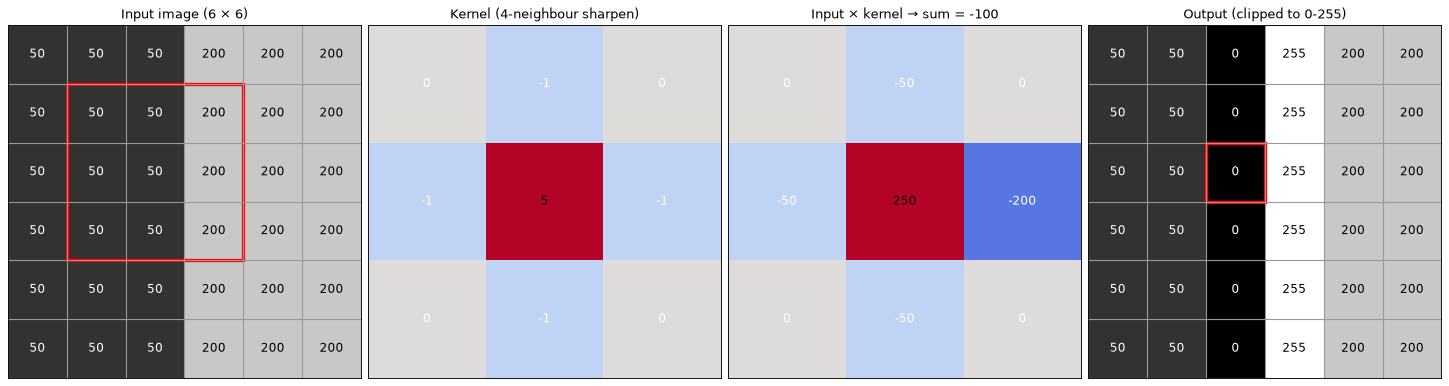

Row 2 before: [ 50  50  50 200 200 200]
Row 2 after:  [  50   50 -100  350  200  200] (before clipping)


In [2]:
def draw_grid(ax: plt.Axes, values: np.ndarray, title: str, cmap: str = "gray",
              vmin: float = 0, vmax: float = 255) -> None:
    """Draw a small 2D array as a grid of coloured cells with the value written in each cell."""
    ax.imshow(values, cmap=cmap, vmin=vmin, vmax=vmax)
    for (row, col), value in np.ndenumerate(values):
        shade = (value - vmin) / (vmax - vmin) if vmax > vmin else 0.5
        ax.text(col, row, f"{value:g}", ha="center", va="center", fontsize=11,
                color="black" if shade > 0.5 else "white")
    ax.set_xticks(np.arange(-0.5, values.shape[1]), minor=True)
    ax.set_yticks(np.arange(-0.5, values.shape[0]), minor=True)
    ax.grid(which="minor", color="0.6", linewidth=1)
    ax.tick_params(which="both", length=0, labelbottom=False, labelleft=False)
    ax.set_title(title)


toy = np.array([[50, 50, 50, 200, 200, 200]] * 6, dtype=np.float32)
toy_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
toy_raw = cv2.filter2D(toy, -1, toy_kernel)          # float result, not clipped yet
toy_out = np.clip(toy_raw, 0, 255)                   # what a uint8 image would store

row, col = 2, 2  # the output pixel computed by hand
patch = toy[row - 1:row + 2, col - 1:col + 2]
products = patch * toy_kernel

fig, axes = plt.subplots(1, 4, figsize=(18, 4.8), layout="constrained")
draw_grid(axes[0], toy, "Input image (6 × 6)")
axes[0].add_patch(Rectangle((col - 1.5, row - 1.5), 3, 3, fill=False, edgecolor="red", linewidth=3))
draw_grid(axes[1], toy_kernel, "Kernel (4-neighbour sharpen)", cmap="coolwarm", vmin=-5, vmax=5)
draw_grid(axes[2], products, f"Input × kernel → sum = {products.sum():g}",
          cmap="coolwarm", vmin=-250, vmax=250)
draw_grid(axes[3], toy_out, "Output (clipped to 0-255)")
axes[3].add_patch(Rectangle((col - 0.5, row - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=3))
plt.show()

print("Row 2 before:", toy[row].astype(int))
print("Row 2 after: ", toy_raw[row].astype(int), "(before clipping)")

Next to the edge, the dark side gets **darker** (50 → −100, clipped to 0) and the bright side gets **brighter** (200 → 350, clipped to 255), while flat areas stay the same because the kernel sums to 1. This overshoot is exactly what makes edges look sharper, and also why strong sharpening creates bright and dark **halos** along edges.

At the image border the kernel sticks out of the image. OpenCV fills the missing pixels by **mirroring** the image (`cv2.BORDER_REFLECT_101` by default), so the output keeps the same size as the input.

## 3. Configuration

- `INPUT_PATH`: the sample image. Image source: <https://www.flickr.com/photos/162308592@N07/47133183871/>
- `SHARPEN_KERNELS`: the two sharpening kernels. Both sum to 1, so brightness is kept.
- `BLUR_SIZES`: the box-blur kernel sizes compared in section 7.
- `ZOOM`: the `(top, bottom, left, right)` region of the "Welcome to Las Vegas" sign used for zoomed crops, where small details make the differences visible.
- `PROFILE_ROW`, `PROFILE_COLS`: a horizontal line across the edge between the white car door and the black triangle, used for intensity profiles.
- `CANNY_THRESHOLDS`: the low and high thresholds for the Canny edge detector in section 9.
- All results are saved to `OUTPUT_DIR`.

In [3]:
INPUT_PATH = Path("Self_Driving_Car.jpg")
OUTPUT_DIR = Path("output")

SHARPEN_KERNELS = {
    "4-neighbour": np.array([[0, -1, 0],
                             [-1, 5, -1],
                             [0, -1, 0]], dtype=np.float32),
    "8-neighbour": np.array([[-1, -1, -1],
                             [-1, 9, -1],
                             [-1, -1, -1]], dtype=np.float32),
}

BLUR_SIZES = (3, 8, 15)  # box-blur kernel sizes compared in section 7

ZOOM = (50, 150, 180, 380)  # (top, bottom, left, right) of the sign
PROFILE_ROW = 330
PROFILE_COLS = (320, 400)  # (start, end) columns across the door / black triangle edge

CANNY_THRESHOLDS = (100, 200)  # (low, high)

## 4. Load the image

`load_image` wraps `cv2.imread`, which returns `None` instead of raising an error when a file is missing. Most of the notebook works on the **grayscale** image, because a single channel makes the effect of each kernel easy to see. Section 6.3 shows that the same kernels also work on colour images.

`show_images` shows several images side by side and `crop` cuts out the `ZOOM` region.

Colour image: shape (426, 640, 3), dtype uint8
Grayscale:    shape (426, 640)


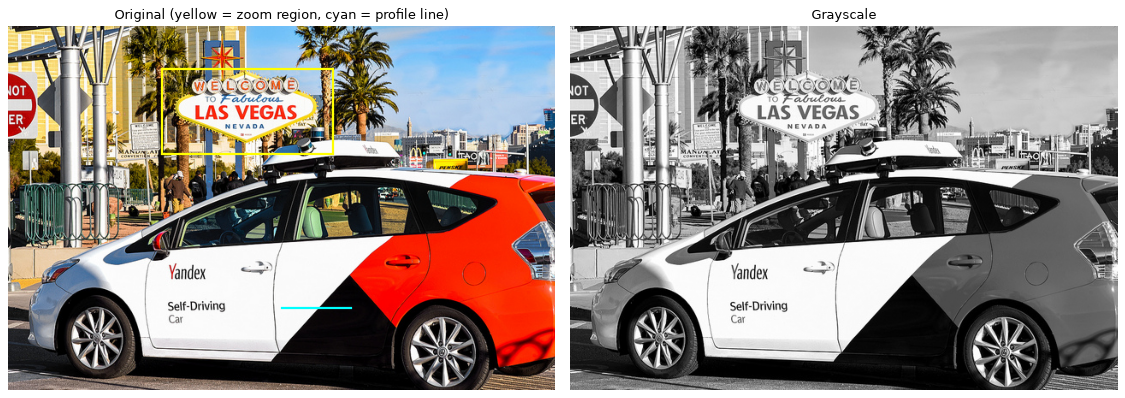

In [4]:
def load_image(path: Path) -> np.ndarray:
    """Load a colour image with OpenCV (BGR order) and raise a clear error if it fails."""
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path.resolve()}")
    return image


def show_images(images: dict[str, np.ndarray], cols: int | None = None, size: float = 5.0) -> None:
    """Show grayscale or RGB images side by side with their titles."""
    cols = cols or len(images)
    rows = -(-len(images) // cols)  # ceiling division
    first = next(iter(images.values()))
    aspect = first.shape[0] / first.shape[1]
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * aspect * rows + 0.5 * rows),
                             layout="constrained", squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, (title, image) in zip(axes.flat, images.items()):
        ax.imshow(image, cmap="gray" if image.ndim == 2 else None, vmin=0, vmax=255)
        ax.set_title(title)
    plt.show()


def crop(image: np.ndarray, region: tuple[int, int, int, int] = ZOOM) -> np.ndarray:
    """Return the (top, bottom, left, right) region of an image."""
    top, bottom, left, right = region
    return image[top:bottom, left:right]


image_bgr = load_image(INPUT_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print(f"Colour image: shape {image_bgr.shape}, dtype {image_bgr.dtype}")
print(f"Grayscale:    shape {gray.shape}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8), layout="constrained")
ax[0].imshow(image_rgb)
top, bottom, left, right = ZOOM
ax[0].add_patch(Rectangle((left, top), right - left, bottom - top, fill=False, edgecolor="yellow", linewidth=2))
ax[0].plot(PROFILE_COLS, (PROFILE_ROW, PROFILE_ROW), color="cyan", linewidth=2)
ax[0].set_title("Original (yellow = zoom region, cyan = profile line)")
ax[1].imshow(gray, cmap="gray", vmin=0, vmax=255)
ax[1].set_title("Grayscale")
for a in ax:
    a.axis("off")
plt.show()

## 5. Applying a kernel

`apply_kernel` is a thin wrapper around `cv2.filter2D(image, ddepth, kernel)`:
- `ddepth=-1` means "same data type as the input", i.e. `uint8`. OpenCV computes in floating point internally and then **clips** the result to 0 – 255 (it doesn't wrap around).
- The kernel should be `float32`, so fractions such as 1/9 are kept exactly.

`show_kernel` draws a kernel as a heat map with its values and its sum, the brightness gain.

In [5]:
def apply_kernel(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Convolve an image with a kernel; the result has the input's dtype and is clipped to its range."""
    return cv2.filter2D(image, ddepth=-1, kernel=kernel.astype(np.float32))


def show_kernel(ax: plt.Axes, kernel: np.ndarray, title: str) -> None:
    """Draw a kernel as a heat map with its values and sum."""
    limit = np.abs(kernel).max()
    draw_grid(ax, np.round(kernel, 3), f"{title}\nsum = {kernel.sum():.3g}",
              cmap="coolwarm", vmin=-limit, vmax=limit)

## 6. Sharpening

### 6.1 Two sharpening kernels

Both kernels keep the pixel (large positive centre) and subtract its neighbours. You can read them as

$$\text{sharpen} = \text{identity} + \text{edges}$$

where the "edges" part (the **Laplacian**) is zero on flat areas and large on edges.
- The **4-neighbour** kernel only uses the pixels above, below, left and right. It is the milder of the two.
- The **8-neighbour** kernel also uses the diagonals. It reacts to edges in every direction and is **stronger**. It is the kernel the section focuses on.

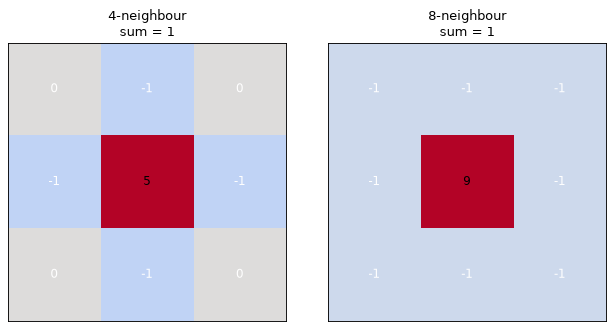

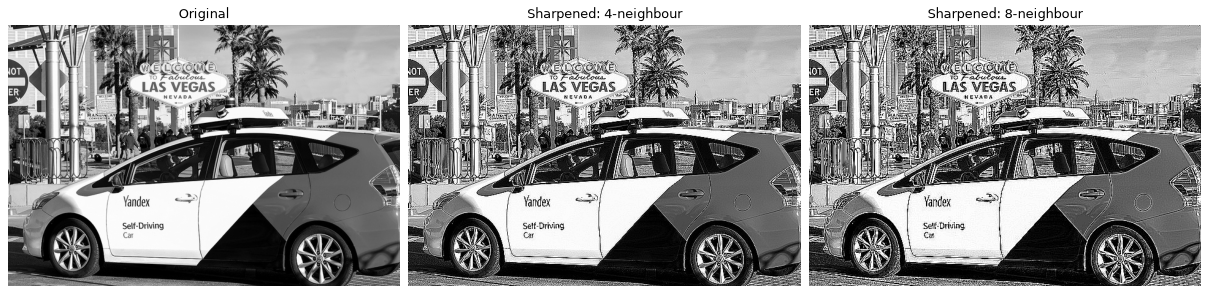

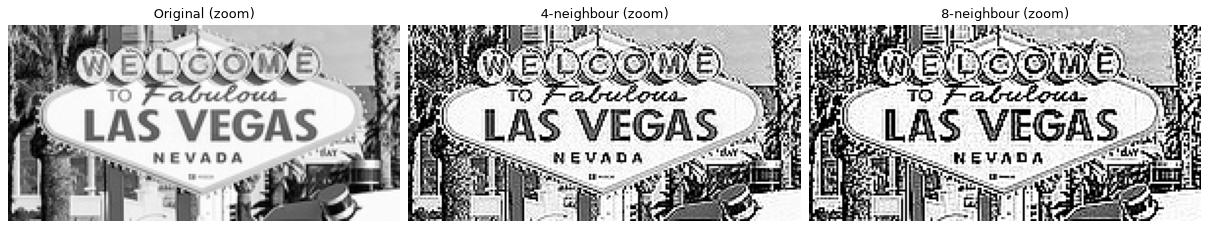

In [6]:
sharpened = {name: apply_kernel(gray, kernel) for name, kernel in SHARPEN_KERNELS.items()}

fig, axes = plt.subplots(1, len(SHARPEN_KERNELS), figsize=(8, 4), layout="constrained")
for ax, (name, kernel) in zip(axes, SHARPEN_KERNELS.items()):
    show_kernel(ax, kernel, name)
plt.show()

show_images({"Original": gray, **{f"Sharpened: {name}": img for name, img in sharpened.items()}})
show_images({"Original (zoom)": crop(gray),
             **{f"{name} (zoom)": crop(img) for name, img in sharpened.items()}})

In the zoomed crops, the letters and the edges of the sign become crisper, but the **noise and JPEG artefacts** in the sky and on the palm trees are amplified too. This is especially visible with the 8-neighbour kernel. Sharpening can't add detail that isn't there; it only increases the contrast of what is already in the image, including the noise.

### 6.2 Unsharp masking

The kernels above have a fixed strength. **Unsharp masking** is the method used by most photo editors, and it lets you choose the strength:

$$\text{sharpened} = \text{image} + \text{amount}\cdot(\text{image} - \text{blurred})$$

`image − blurred` contains only the fine detail, so adding it back emphasises that detail. `amount` controls the strength and `sigma` (the size of the blur) controls how fine the details are that get sharpened. `cv2.addWeighted` computes this in one saturating step.

`sharpen` below offers both solutions: a kernel or unsharp masking.

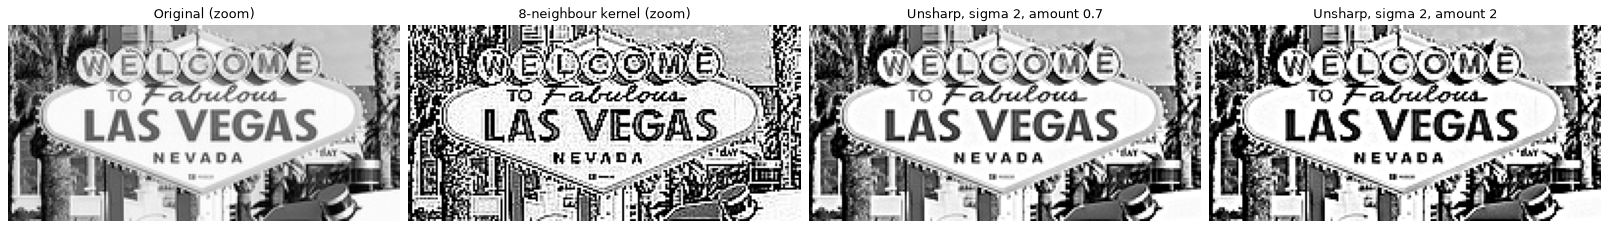

In [7]:
def unsharp_mask(image: np.ndarray, sigma: float = 2.0, amount: float = 1.0) -> np.ndarray:
    """Sharpen with image + amount * (image - GaussianBlur(image, sigma)), clipped to the dtype range."""
    blurred = cv2.GaussianBlur(image, ksize=(0, 0), sigmaX=sigma)
    return cv2.addWeighted(image, 1 + amount, blurred, -amount, 0)


def sharpen(image: np.ndarray, method: str = "unsharp", **kwargs: float) -> np.ndarray:
    """Sharpen with method "4-neighbour" or "8-neighbour" (kernels) or "unsharp" (unsharp masking)."""
    if method in SHARPEN_KERNELS:
        return apply_kernel(image, SHARPEN_KERNELS[method])
    if method == "unsharp":
        return unsharp_mask(image, **kwargs)
    raise ValueError(f"Unknown method: {method!r}")


show_images({
    "Original (zoom)": crop(gray),
    "8-neighbour kernel (zoom)": crop(sharpen(gray, "8-neighbour")),
    "Unsharp, sigma 2, amount 0.7": crop(sharpen(gray, "unsharp", sigma=2, amount=0.7)),
    "Unsharp, sigma 2, amount 2": crop(sharpen(gray, "unsharp", sigma=2, amount=2)),
})

With a moderate `amount`, unsharp masking makes the sign look crisper while boosting the fine noise much less than the 8-neighbour kernel, because the Gaussian blur leaves out the finest, pixel-level noise. A large `amount` gives the same halos as the strong kernel.

### 6.3 Sharpening a colour image

`cv2.filter2D` applies the kernel to **each channel separately**, so the same function works on a BGR colour image without any changes.

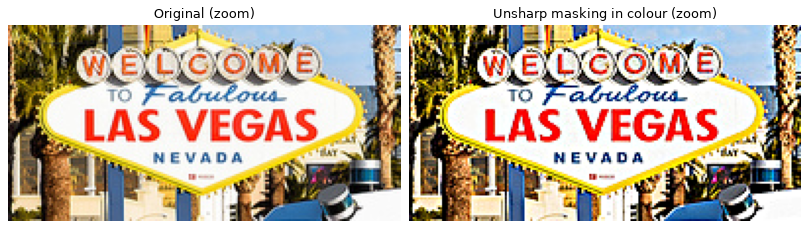

In [8]:
sharpened_bgr = sharpen(image_bgr, "unsharp", sigma=2, amount=1)
show_images({
    "Original (zoom)": crop(image_rgb),
    "Unsharp masking in colour (zoom)": crop(cv2.cvtColor(sharpened_bgr, cv2.COLOR_BGR2RGB)),
})

## 7. Blurring

### 7.1 Why the kernel must be normalised

The simplest blur is the **box kernel**: every value is the same, so each output pixel is the average of its neighbourhood.

A kernel of all ones, `np.ones((3, 3))`, doesn't compute the average but the **sum** of 9 pixels. Its sum is 9, so the image becomes 9 × brighter, and almost every pixel is clipped to 255 (white). Dividing by the number of elements (**normalising**) makes the sum 1, and the brightness stays the same:

$$K_{3\times3} = \frac{1}{9}\begin{bmatrix}1&1&1\\1&1&1\\1&1&1\end{bmatrix}$$

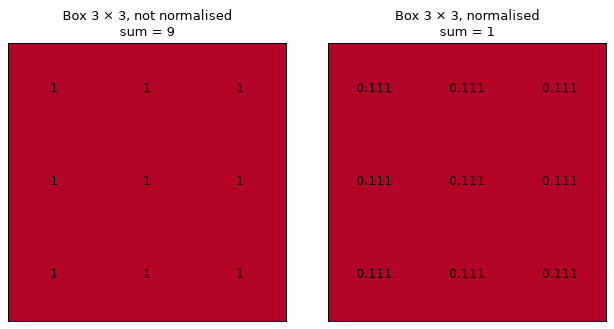

original        mean brightness  127.4, pixels at 255:   0.7%
not normalised  mean brightness  229.7, pixels at 255:  83.5%
normalised      mean brightness  127.4, pixels at 255:   0.0%


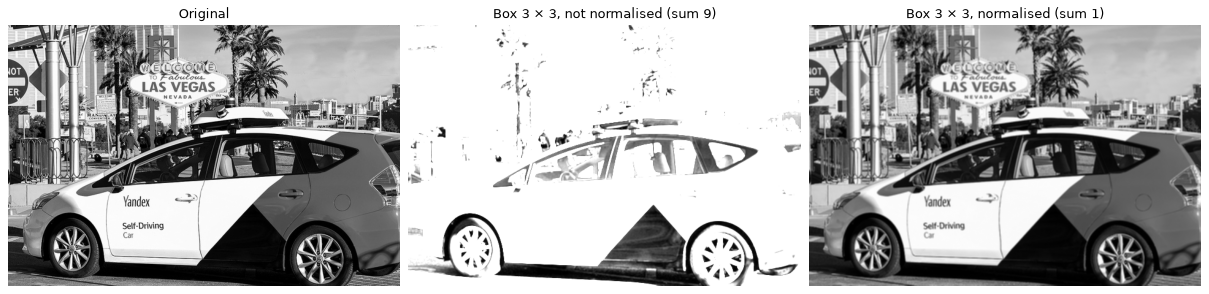

In [9]:
def box_kernel(size: int, normalize: bool = True) -> np.ndarray:
    """Return a size x size box kernel; normalised kernels sum to 1."""
    kernel = np.ones((size, size), dtype=np.float32)
    return kernel / kernel.size if normalize else kernel


blur_unnormalized = apply_kernel(gray, box_kernel(3, normalize=False))
blur_normalized = apply_kernel(gray, box_kernel(3))

fig, axes = plt.subplots(1, 2, figsize=(8, 4), layout="constrained")
show_kernel(axes[0], box_kernel(3, normalize=False), "Box 3 × 3, not normalised")
show_kernel(axes[1], box_kernel(3), "Box 3 × 3, normalised")
plt.show()

for name, image in {"original": gray, "not normalised": blur_unnormalized,
                    "normalised": blur_normalized}.items():
    print(f"{name:15s} mean brightness {image.mean():6.1f}, "
          f"pixels at 255: {np.mean(image == 255):6.1%}")

show_images({"Original": gray, "Box 3 × 3, not normalised (sum 9)": blur_unnormalized,
             "Box 3 × 3, normalised (sum 1)": blur_normalized})

### 7.2 Kernel size

A larger kernel averages over more pixels, so the blur is **stronger**. The effect grows quickly: a 15 × 15 kernel averages 225 pixels.

The not normalised 8 × 8 kernel would sum to 64, which makes the image almost completely white. Always normalise.

> ⚠️ **Prefer odd kernel sizes** (3, 5, 7, …). An odd kernel has a centre pixel, so the output is aligned with the input. An **even** kernel such as 8 × 8 has no centre; OpenCV uses the pixel just below and to the right of the middle as the anchor, which shifts the blurred image by **half a pixel**. That's invisible here, but it matters when you compare or combine images pixel by pixel.

`cv2.blur(image, (k, k))` is OpenCV's built-in normalised box blur. It gives the same result as `filter2D` with a normalised box kernel (at most 1 gray value apart, because the two functions round slightly differently), and is the more readable choice.

 3 × 3  box: max difference filter2D vs. cv2.blur = 0
 8 × 8  box: max difference filter2D vs. cv2.blur = 1
15 × 15 box: max difference filter2D vs. cv2.blur = 0


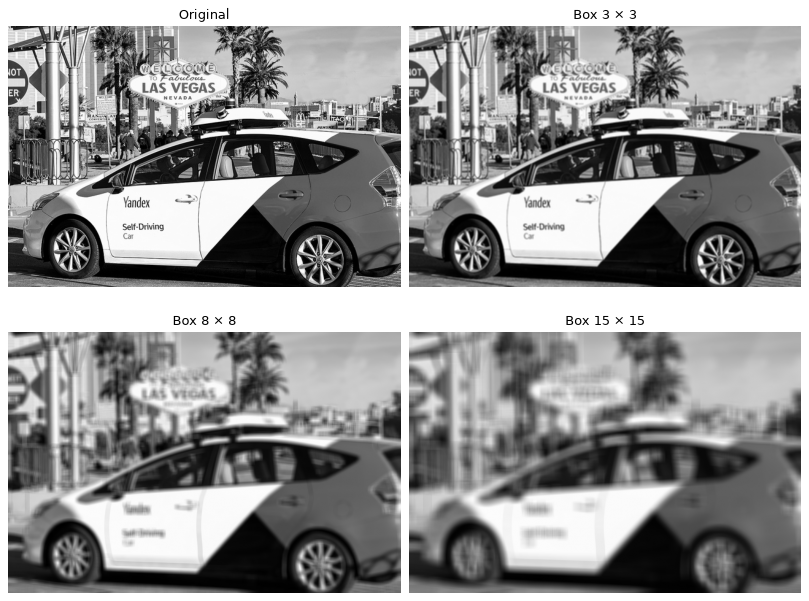

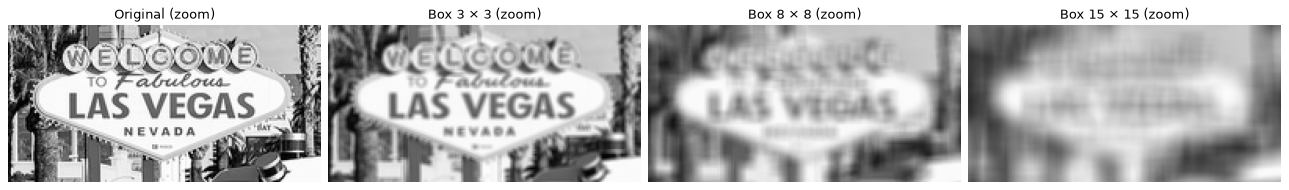

In [10]:
box_blurs = {size: apply_kernel(gray, box_kernel(size)) for size in BLUR_SIZES}

for size, image in box_blurs.items():
    max_diff = int(np.abs(image.astype(int) - cv2.blur(gray, (size, size))).max())
    print(f"{size:2d} × {size:<2d} box: max difference filter2D vs. cv2.blur = {max_diff}")

show_images({"Original": gray, **{f"Box {s} × {s}": img for s, img in box_blurs.items()}}, cols=2)
show_images({"Original (zoom)": crop(gray),
             **{f"Box {s} × {s} (zoom)": crop(img) for s, img in box_blurs.items()}}, cols=4, size=4)

### 7.3 Intensity profile across an edge

The profile below follows the cyan line from section 4, across the edge from the white car door to the black triangle. It shows numerically what blurring and sharpening do to an edge:
- **Blurring** turns the sharp step into a **ramp**. The larger the kernel, the wider the ramp.
- **Sharpening** keeps the step and adds an **overshoot** on both sides, but here it can't go beyond 255 or below 0, so the overshoot is clipped on this high-contrast edge. The small wobbles in the flat parts are amplified noise.

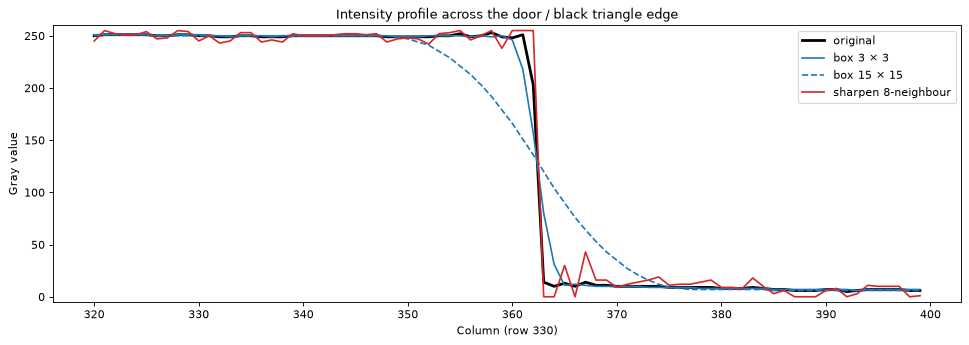

In [11]:
cols = np.arange(*PROFILE_COLS)
profiles = {
    "original": gray,
    "box 3 × 3": box_blurs[3],
    "box 15 × 15": box_blurs[15],
    "sharpen 8-neighbour": sharpened["8-neighbour"],
}
styles = {"original": ("black", "-", 2.5), "box 3 × 3": ("tab:blue", "-", 1.5),
          "box 15 × 15": ("tab:blue", "--", 1.5), "sharpen 8-neighbour": ("tab:red", "-", 1.5)}

fig, ax = plt.subplots(figsize=(12, 4.2), layout="constrained")
for name, image in profiles.items():
    color, linestyle, width = styles[name]
    ax.plot(cols, image[PROFILE_ROW, cols], label=name, color=color, linestyle=linestyle, linewidth=width)
ax.set_xlabel(f"Column (row {PROFILE_ROW})")
ax.set_ylabel("Gray value")
ax.set_ylim(-5, 260)
ax.legend()
ax.set_title("Intensity profile across the door / black triangle edge")
plt.show()

## 8. Comparing blur methods

The box blur is only one of several solutions. OpenCV offers four common blur methods, and `blur` below wraps all of them:

| Method | How it works | Strength | Weakness |
|---|---|---|---|
| **Box** (`cv2.blur`) | Plain average of the neighbourhood | Fastest | Blocky; all neighbours count equally |
| **Gaussian** (`cv2.GaussianBlur`) | Weighted average; close pixels count more (bell curve) | Smooth, natural blur; standard before edge detection | Blurs edges as much as noise |
| **Median** (`cv2.medianBlur`) | Median of the neighbourhood (not a convolution) | Removes salt-and-pepper noise, keeps edges fairly sharp | Slower; can round off fine detail |
| **Bilateral** (`cv2.bilateralFilter`) | Gaussian that also ignores pixels with a very different value | Smooths flat areas and **keeps edges** | Slowest; can look "painted" |

The Gaussian kernel is shown as a heat map as well: its values are largest in the centre and fall off smoothly, and it sums to 1 like every blur kernel.

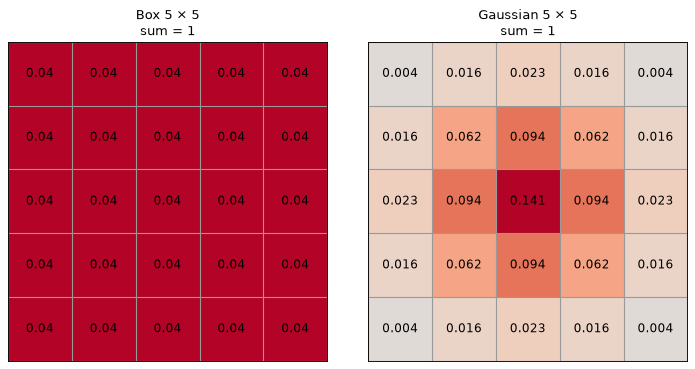

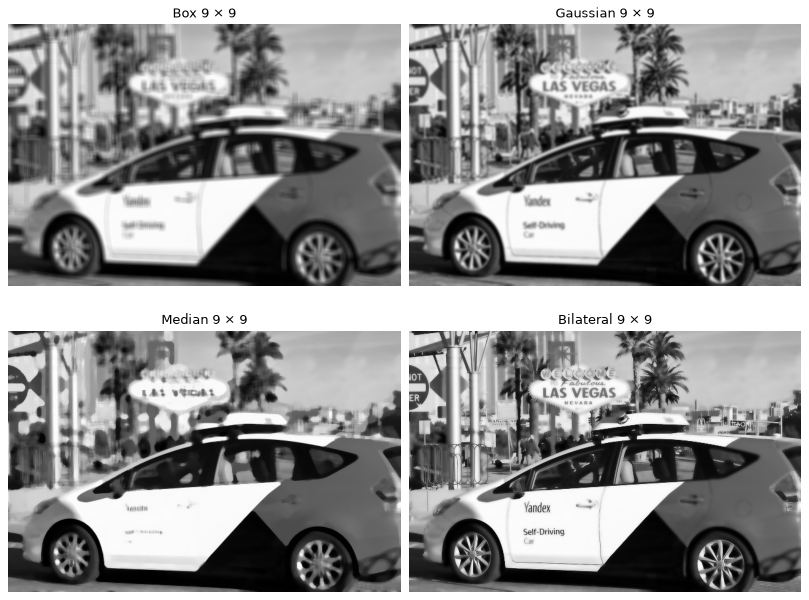

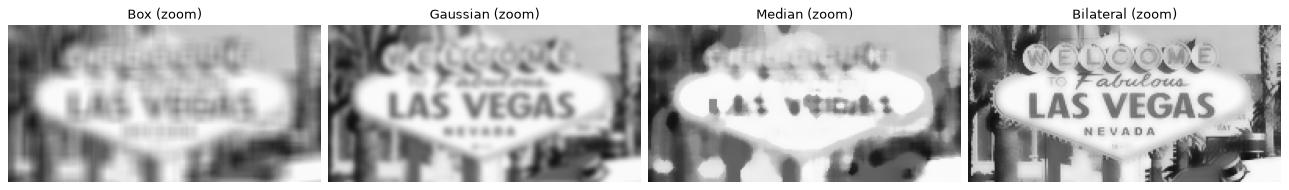

In [12]:
def blur(image: np.ndarray, method: str = "gaussian", size: int = 5) -> np.ndarray:
    """Blur with method "box", "gaussian", "median" or "bilateral"; size is the (odd) neighbourhood size."""
    if size % 2 == 0:
        raise ValueError(f"Use an odd kernel size, got {size}")
    if method == "box":
        return cv2.blur(image, (size, size))
    if method == "gaussian":
        return cv2.GaussianBlur(image, (size, size), sigmaX=0)  # sigma derived from size
    if method == "median":
        return cv2.medianBlur(image, size)
    if method == "bilateral":
        return cv2.bilateralFilter(image, d=size, sigmaColor=75, sigmaSpace=75)
    raise ValueError(f"Unknown method: {method!r}")


BLUR_METHODS = ("box", "gaussian", "median", "bilateral")
BLUR_SIZE = 9
blurred = {method: blur(gray, method, BLUR_SIZE) for method in BLUR_METHODS}

gauss_1d = cv2.getGaussianKernel(5, sigma=0)
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), layout="constrained")
show_kernel(axes[0], box_kernel(5), "Box 5 × 5")
show_kernel(axes[1], (gauss_1d @ gauss_1d.T).astype(np.float32), "Gaussian 5 × 5")
plt.show()

show_images({f"{m.capitalize()} {BLUR_SIZE} × {BLUR_SIZE}": img for m, img in blurred.items()}, cols=2)
show_images({f"{m.capitalize()} (zoom)": crop(img) for m, img in blurred.items()}, cols=4, size=4)

With the same 9 × 9 neighbourhood:
- **Box** is the blurriest and slightly blocky.
- **Gaussian** is softer than box for the same size, because the far pixels count less.
- **Median** keeps large outlines, such as the border of the sign and the poles, sharp, but a 9 × 9 window is too large for thin details: the palm leaves become flat blobs and the small letters almost disappear.
- **Bilateral** smooths the sky and the flat areas of the sign while keeping the edges of the letters crisp.

## 9. Why blur before edge detection?

Edge detectors such as **Canny** look for large changes in brightness. Noise and fine texture (asphalt, leaves, JPEG artefacts) also produce many small changes, which show up as short, useless edges. A Gaussian blur first removes this fine detail, so mainly the **real** outlines remain. This is why a classic lane detection pipeline runs `GaussianBlur` → `Canny`.

`canny_edges` returns the Canny edge map, and the cell prints the share of edge pixels, so the effect can be measured.

Canny on original                      edge pixels:  44,355 (16.3%)
Canny after Gaussian 5 × 5             edge pixels:  31,395 (11.5%)
Canny after sharpening (8-neighbour)   edge pixels:  61,689 (22.6%)


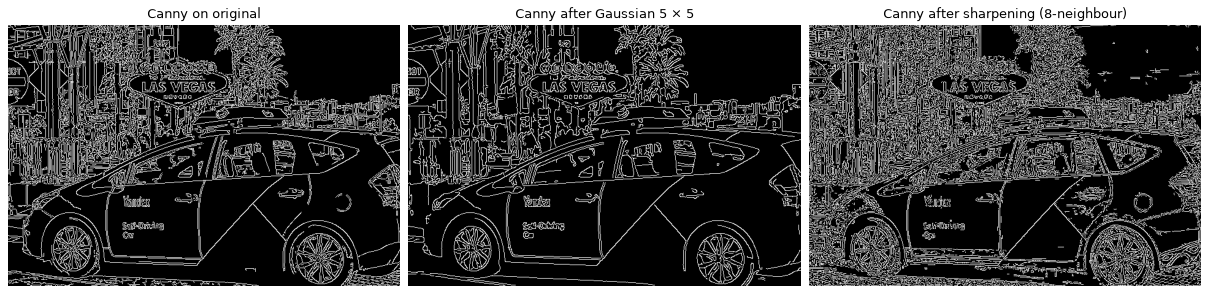

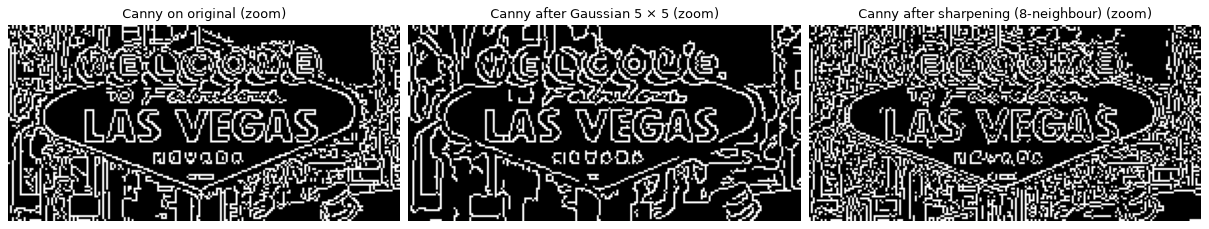

In [13]:
def canny_edges(image: np.ndarray, thresholds: tuple[int, int] = CANNY_THRESHOLDS) -> np.ndarray:
    """Return the Canny edge map (0 or 255) of a grayscale image."""
    low, high = thresholds
    return cv2.Canny(image, low, high)


edges = {
    "Canny on original": canny_edges(gray),
    "Canny after Gaussian 5 × 5": canny_edges(blur(gray, "gaussian", 5)),
    "Canny after sharpening (8-neighbour)": canny_edges(sharpened["8-neighbour"]),
}
for name, edge_map in edges.items():
    print(f"{name:38s} edge pixels: {np.count_nonzero(edge_map):7,} ({np.mean(edge_map > 0):.1%})")

show_images(edges)
show_images({f"{name} (zoom)": crop(img) for name, img in edges.items()})

The Gaussian blur removes about 30 % of the edge pixels. Most of the removed ones came from the palm leaves, the background buildings and the texture of the sky, while the outlines of the car, the sign and its letters remain. Sharpening does the opposite: it amplifies noise, so Canny finds far **more** tiny edges. For edge detection, **blur, don't sharpen**.

## 10. Save the results

All results are written to `OUTPUT_DIR`. `save_image` checks the return value, because `cv2.imwrite` returns `False` instead of raising an error when saving fails.

In [14]:
def save_image(path: Path, image: np.ndarray) -> None:
    """Save a BGR or single-channel image with OpenCV, raising an error if it fails."""
    path.parent.mkdir(parents=True, exist_ok=True)
    if not cv2.imwrite(str(path), image):
        raise OSError(f"Could not write image: {path.resolve()}")
    print(f"Saved {path}")


stem = INPUT_PATH.stem
outputs = {
    "gray": gray,
    "sharpen_4_neighbour": sharpened["4-neighbour"],
    "sharpen_8_neighbour": sharpened["8-neighbour"],
    "sharpen_unsharp_color": sharpened_bgr,
    "blur_box_3x3_not_normalized": blur_unnormalized,
    **{f"blur_box_{s}x{s}": img for s, img in box_blurs.items()},
    **{f"blur_{m}_{BLUR_SIZE}x{BLUR_SIZE}": img for m, img in blurred.items()},
    "canny_original": edges["Canny on original"],
    "canny_gaussian_5x5": edges["Canny after Gaussian 5 × 5"],
}
for suffix, image in outputs.items():
    save_image(OUTPUT_DIR / f"{stem}_{suffix}.jpg", image)

Saved output/Self_Driving_Car_gray.jpg
Saved output/Self_Driving_Car_sharpen_4_neighbour.jpg
Saved output/Self_Driving_Car_sharpen_8_neighbour.jpg
Saved output/Self_Driving_Car_sharpen_unsharp_color.jpg
Saved output/Self_Driving_Car_blur_box_3x3_not_normalized.jpg
Saved output/Self_Driving_Car_blur_box_3x3.jpg
Saved output/Self_Driving_Car_blur_box_8x8.jpg
Saved output/Self_Driving_Car_blur_box_15x15.jpg
Saved output/Self_Driving_Car_blur_box_9x9.jpg
Saved output/Self_Driving_Car_blur_gaussian_9x9.jpg
Saved output/Self_Driving_Car_blur_median_9x9.jpg
Saved output/Self_Driving_Car_blur_bilateral_9x9.jpg
Saved output/Self_Driving_Car_canny_original.jpg
Saved output/Self_Driving_Car_canny_gaussian_5x5.jpg


## 11. Conclusion

- **Convolution** slides a small kernel over the image and replaces every pixel with a weighted sum of its neighbourhood. The kernel alone decides what the filter does, and its **sum** decides the brightness: keep it at 1.
- **Sharpening** kernels have a large positive centre and negative neighbours (identity + edges). They make edges crisper, but amplify noise and cause halos. The 8-neighbour kernel is stronger than the 4-neighbour kernel. **Unsharp masking** gives adjustable, cleaner sharpening.
- **Blurring** averages the neighbourhood. A box kernel must be **normalised** (divided by the number of elements), otherwise the image turns white. Larger kernels blur more, and **odd sizes** keep the output aligned with the input.
- **Blur methods:** box is the fastest, Gaussian the standard, median is best against salt-and-pepper noise, and bilateral smooths while keeping edges.
- **For lane detection:** a Gaussian blur before Canny removes most of the noise edges while keeping the real outlines. Sharpening before edge detection does the opposite.

**Next step for lane detection:** use `GaussianBlur` + `Canny` on the road image, combine the edges with the region-of-interest mask from the earlier notebook, and find the lane lines with the **Hough transform**.